# Unemployment Analysis with Python
**CodeAlpha Data Science Internship, Task 2**

For this task I'm looking at unemployment rate data across Indian states to understand how it moved over time, especially around the Covid-19 lockdown, and to pull out a few patterns that could be useful from a policy standpoint.

## 1. Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# just a plot style I'll reuse throughout the notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Loading the dataset

In [2]:
# stripping the column names since the raw CSV has extra whitespace in the headers
df = pd.read_csv("data/Unemployment_in_India.csv")
df.columns = df.columns.str.strip()
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
print(df.shape)
df.info()

(768, 7)
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    str    
 1   Date                                     740 non-null    str    
 2   Frequency                                740 non-null    str    
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


## 3. Cleaning the data

In [4]:
# a few rows at the bottom of the file are completely empty, so those get dropped
print("Missing values before cleanup:\n", df.isnull().sum())
df = df.dropna(how="all").dropna()
print("\nShape after dropping empty rows:", df.shape)

Missing values before cleanup:
 Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

Shape after dropping empty rows: (740, 7)


In [5]:
# trimming whitespace from the text columns and converting Date to an actual datetime
for col in ["Region", "Frequency", "Area"]:
    df[col] = df[col].astype(str).str.strip()

df["Date"] = pd.to_datetime(df["Date"].astype(str).str.strip(), format="%d-%m-%Y")
df = df.rename(columns={
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate",
})
df["Month"] = df["Date"].dt.month_name()
df["Year"] = df["Date"].dt.year
df.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Month,Year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,May,2019
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,June,2019
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,July,2019
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,August,2019
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,September,2019


## 4. Exploring the data

In [6]:
df.describe()

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,Year
count,740,740.000000,7.400000e+02,740.000000,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122,2019.418919
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000,2019.000000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500,2019.000000
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000,2019.000000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000,2020.000000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000,2020.000000
std,NaN,10.721298,8.087988e+06,8.111094,0.493716


In [7]:
print("States/regions covered:", df["Region"].nunique())
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("\nArea breakdown:\n", df["Area"].value_counts())

States/regions covered: 28
Date range: 2019-05-31 to 2020-06-30

Area breakdown:
 Area
Urban    381
Rural    359
Name: count, dtype: int64


### 4.1 How unemployment moved nationally over time

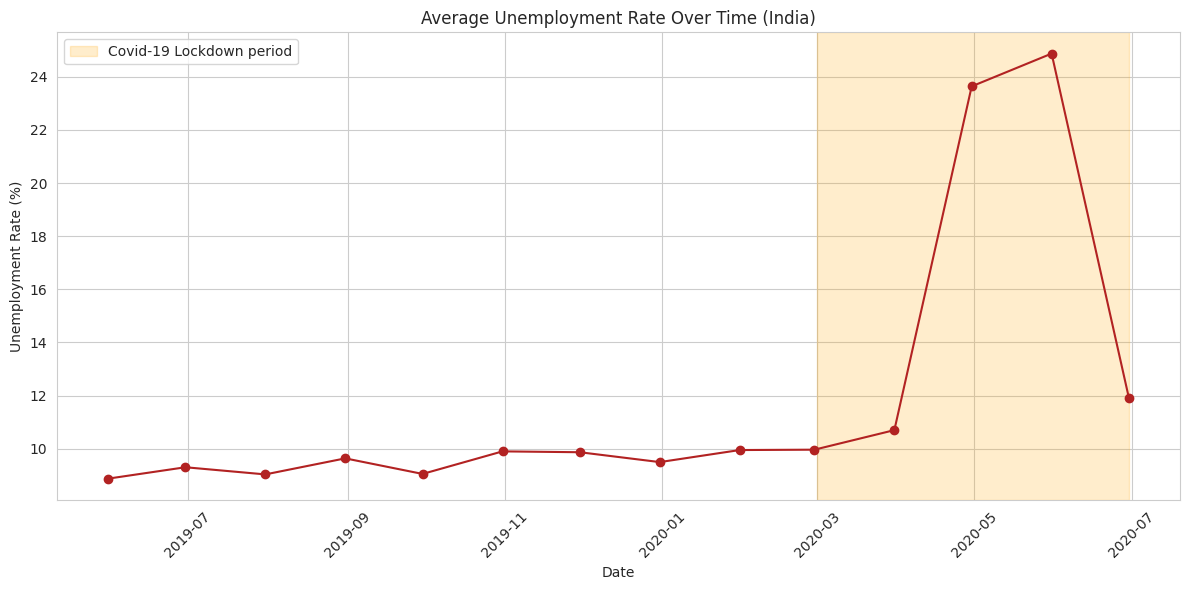

In [8]:
national_trend = df.groupby("Date")["Unemployment_Rate"].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(national_trend["Date"], national_trend["Unemployment_Rate"], marker="o", color="firebrick")
plt.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-06-30"), color="orange", alpha=0.2, label="Covid-19 Lockdown period")
plt.title("Average Unemployment Rate Over Time (India)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**What stands out:** there's a sharp, hard-to-miss spike in unemployment around April 2020. That lines up almost exactly with the nationwide Covid-19 lockdown. Rates jump dramatically and then ease back down gradually over the following months.

### 4.2 Comparing urban and rural unemployment

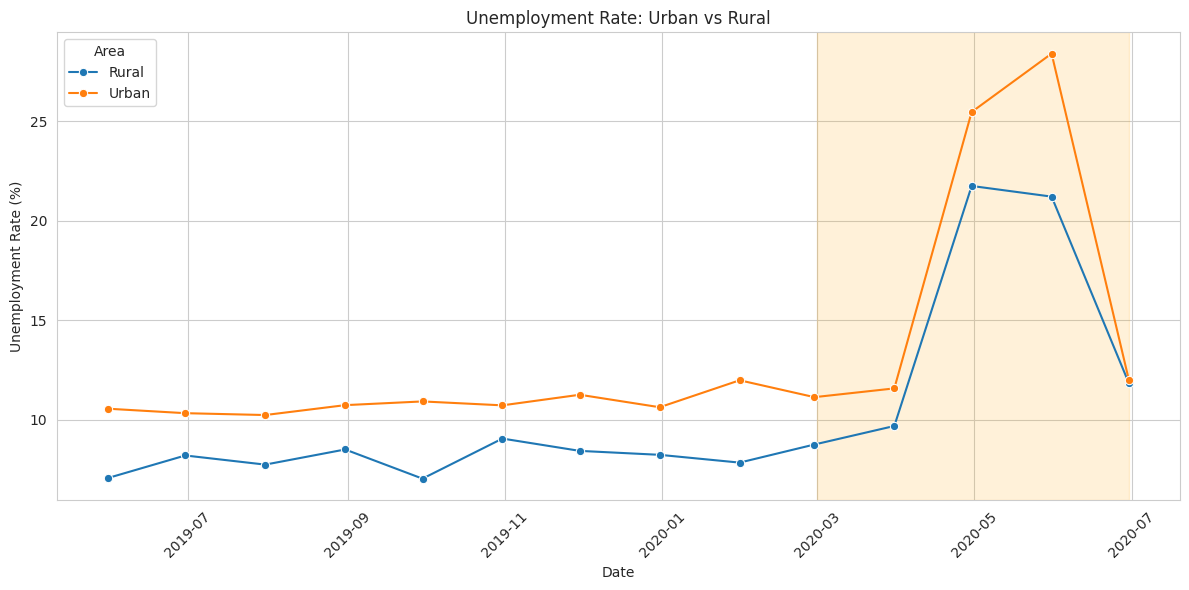

In [9]:
area_trend = df.groupby(["Date", "Area"])["Unemployment_Rate"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=area_trend, x="Date", y="Unemployment_Rate", hue="Area", marker="o")
plt.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-06-30"), color="orange", alpha=0.15)
plt.title("Unemployment Rate: Urban vs Rural")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**What stands out:** urban areas tend to run a higher baseline unemployment rate than rural ones, and the pandemic spike hit cities noticeably harder. That tracks with what you'd expect, since lockdown restrictions hit city-based jobs and services more directly than rural or agricultural work.

### 4.3 Which states had the highest and lowest unemployment

In [ ]:
state_avg = df.groupby("Region")["Unemployment_Rate"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(x=state_avg.values, y=state_avg.index, hue=state_avg.index,
            palette="rocket", legend=False)
plt.title("Average Unemployment Rate by State/Region")
plt.xlabel("Average Unemployment Rate (%)")
plt.tight_layout()
plt.show()

In [11]:
print("Top 5 highest average unemployment:\n", state_avg.head(5))
print("\nTop 5 lowest average unemployment:\n", state_avg.tail(5))

Top 5 highest average unemployment:
 Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Name: Unemployment_Rate, dtype: float64

Top 5 lowest average unemployment:
 Region
Gujarat        6.663929
Uttarakhand    6.582963
Assam          6.428077
Odisha         5.657857
Meghalaya      4.798889
Name: Unemployment_Rate, dtype: float64


### 4.4 Looking for seasonal patterns by month

In [ ]:
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
monthly_avg = df.groupby("Month")["Unemployment_Rate"].mean().reindex(month_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, hue=monthly_avg.index,
            palette="crest", legend=False)
plt.title("Average Unemployment Rate by Month (all years combined)")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.5 Unemployment versus labour participation

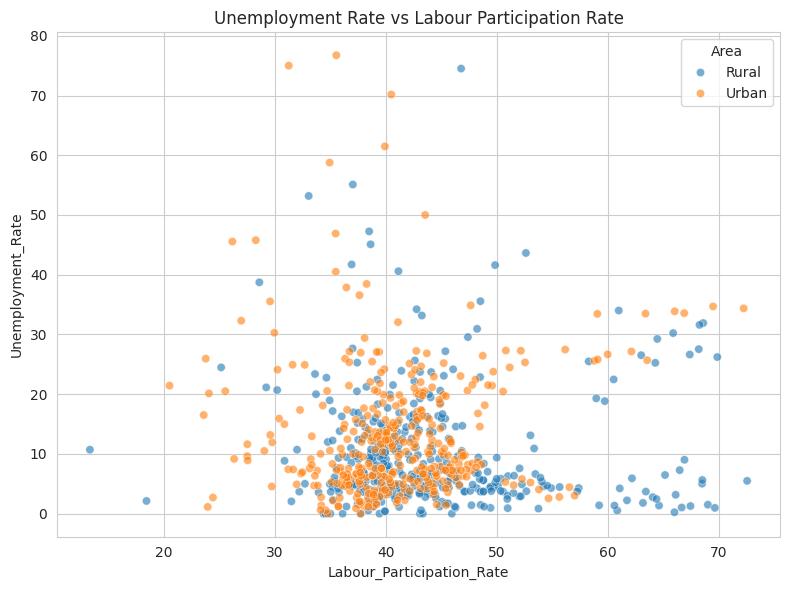

Correlation: 0.003


In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Labour_Participation_Rate", y="Unemployment_Rate", hue="Area", alpha=0.6)
plt.title("Unemployment Rate vs Labour Participation Rate")
plt.tight_layout()
plt.show()

print("Correlation:", df["Unemployment_Rate"].corr(df["Labour_Participation_Rate"]).round(3))

### 4.6 Correlation between the numeric columns

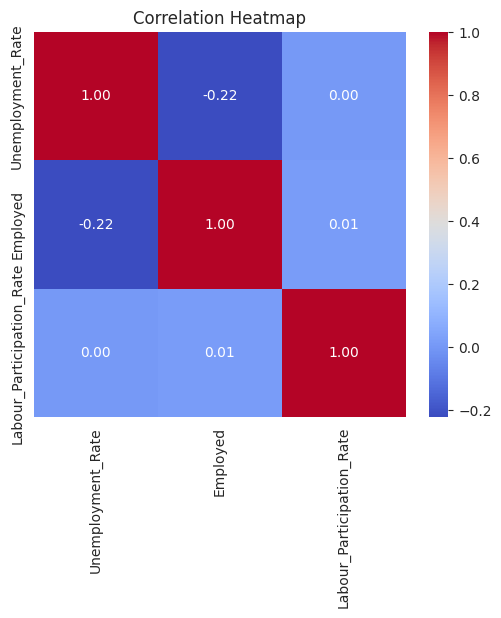

In [14]:
numeric_cols = ["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 5. What I'm taking away from this

1. The Covid-19 impact is impossible to miss. Unemployment spiked sharply around April and May 2020 in almost every state, right when the national lockdown hit, and then slowly recovered over the following months.
2. Urban areas got hit harder than rural areas during that spike, and they also tend to run a higher baseline unemployment rate overall.
3. There are pretty large gaps between states. Some regions consistently sit well above the national average, which suggests there might be structural or regional labour market issues going on, not just pandemic effects.
4. Unemployment and labour participation seem connected. Periods or states with lower labour participation show somewhat different unemployment patterns, which could be useful for designing more targeted policy.

## 6. A few policy ideas based on what the data shows
- Focus urban employment support programs first, since that's where the Covid-era spike hit hardest.
- Target states that show persistently high unemployment with skill development and job creation programs, instead of applying one national policy everywhere.
- Set up some kind of early warning system using monthly unemployment trends, so future shocks like another pandemic or an economic downturn can trigger a faster government response.